In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rich import print
import xarray as xr
import shutil

In [ ]:
#import data
#imerg: Begin: 	2000-06-01T0000+00 End: 	2025-10-01T0000+00
#ERA5_LAND: 1950-01-01T01:00:00Z–2026-03-23T23:00:00Z
# CHIRPS: 1981-01-01T00:00:00Z–2026-02-28T00:00:00Z

# OPEN ET: 1999 - 2024
# Grace: 2002-04-01T00:00:00Z–2017-01-07T00:00:00Z
# MODIS: 2000 - 2025 
precipitation = 
evaporation =  
temperature = 

# Calibration period
calibration_start_time = "2011-01-01T00:00:00Z"
calibration_end_time = "2011-12-31T00:00:00Z"

# Validation period
validation_start_time = "2011-01-01T00:00:00Z"
validation_end_time = "2011-12-31T00:00:00Z"

growing_season_mask = #april to october 

In [31]:
### precipitation April until October every year
imerg = pd.read_csv("Moselle_NASA_GPM_L3_IMERG_MONTHLY_V07_precipitation_2000-06-01_2025-10-01.csv")
imerg['datetime'] = pd.to_datetime(imerg['system:index'], format='%Y%m%d%H%M%S')
hours_in_month = imerg['datetime'].dt.days_in_month * 24
imerg['precipitation_mm'] = imerg['precipitation'] * hours_in_month
imerg = imerg[imerg['datetime'].dt.month.between(4, 10)]

era5_precip = pd.read_csv("Moselle_ECMWF_ERA5_LAND_MONTHLY_AGGR_total_precipitation_sum_2000-06-01_2025-10-01.csv")
era5_precip['datetime'] = pd.to_datetime(era5_precip['system:index'], format='%Y%m')
era5_precip['monthly'] = era5_precip['total_precipitation_sum'] * 1000
era5_precip = era5_precip[era5_precip['datetime'].dt.month.between(4, 10)]

#chirps = pd.read_csv("Moselle_UCSB-CHG_CHIRPS_DAILY_precipitation_2010-01-01_2013-01-01.csv") #mm/d
#chirps['datetime'] = pd.to_datetime(chirps['system:index'], format='%Y%m%d')
#chirps = chirps.groupby(chirps['datetime'].dt.to_period('M'))['precipitation'].sum().reset_index()
#chirps.columns = ['month', 'monthly']

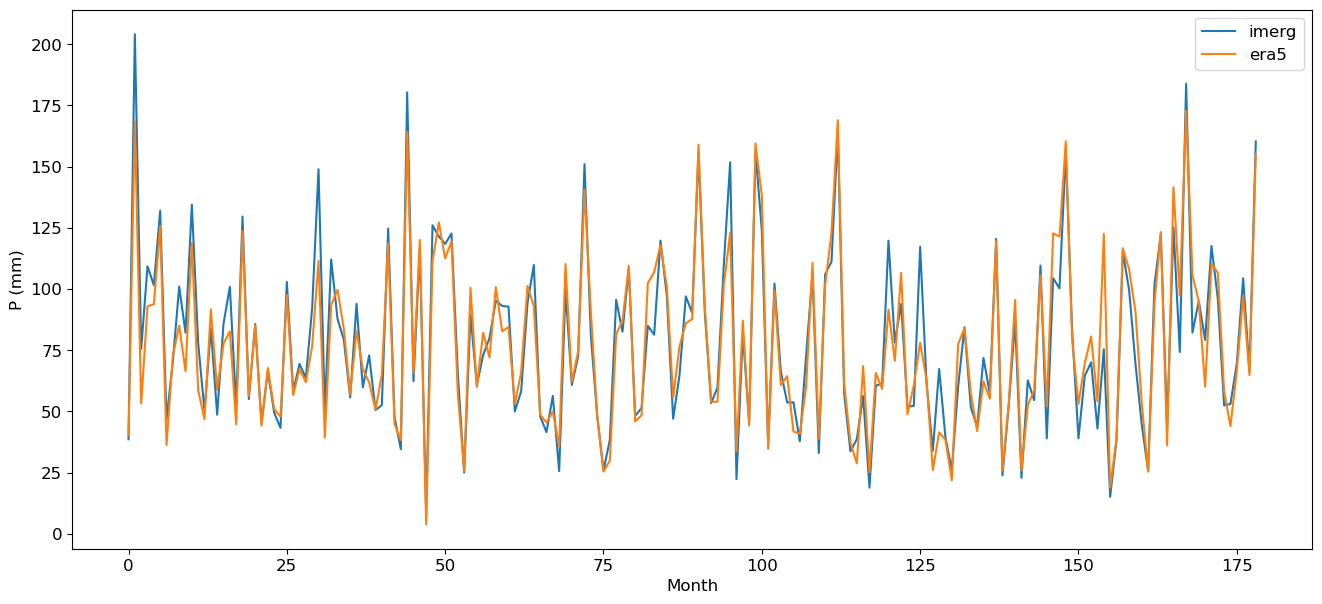

In [39]:
# Read and plot the monthly precipitation data
PObs1 = imerg['precipitation_mm'].to_numpy()
PObs2 = era5_precip['monthly'].to_numpy()
#PObs3 = chirps['monthly'].to_numpy()

plt.figure(figsize=(16,7))
plt.plot(PObs1, label='imerg')
plt.plot(PObs2, label='era5')
#plt.plot(PObs3, label='chirps')
plt.legend()
plt.xlabel('Month')
plt.ylabel('P (mm)');
plt.rcParams["font.size"] = 12

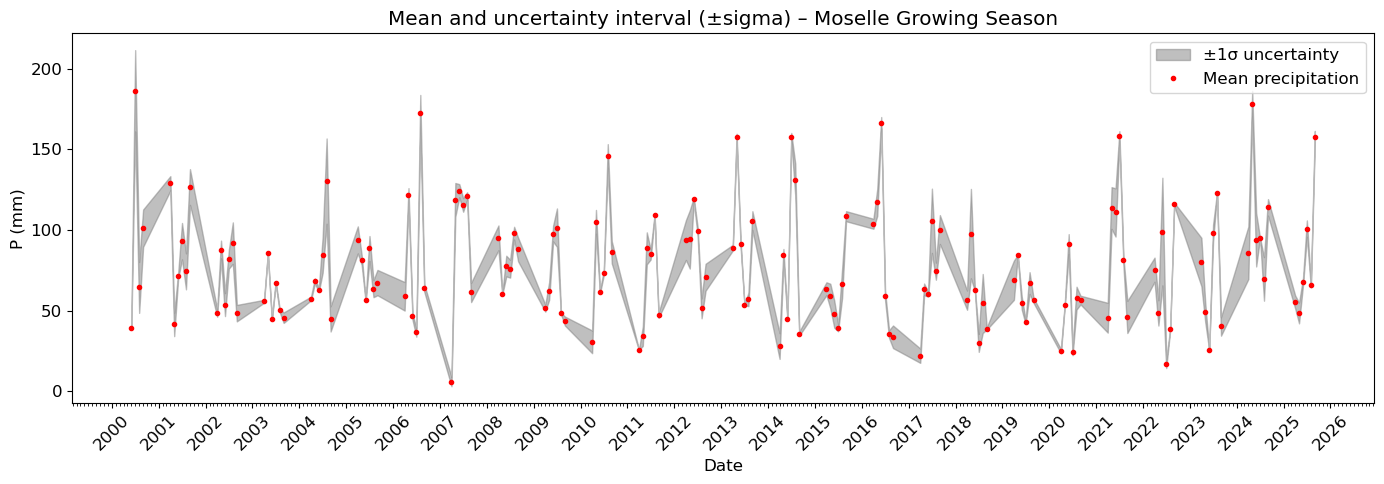

In [30]:
# Plot monthly mean and uncertainty interval (+-sigma) of precipitation
import matplotlib.dates as mdates

merged = pd.merge(imerg[['datetime', 'precipitation_mm']], 
                  era5_precip[['datetime', 'monthly']], 
                  on='datetime', how='inner')

merged['mP'] = (merged['precipitation_mm'] + merged['monthly']) / 2
merged['vP'] = (np.square(merged['precipitation_mm'] - merged['mP']) + 
                np.square(merged['monthly'] - merged['mP'])) / (2 - 1)

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(merged['datetime'], 
                merged['mP'] - np.sqrt(merged['vP']), 
                merged['mP'] + np.sqrt(merged['vP']), 
                color='grey', alpha=0.5, label='±1σ uncertainty')

ax.plot(merged['datetime'], merged['mP'], 'r.', label='Mean precipitation')

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.set_xlabel('Date')
ax.set_ylabel('P (mm)')
ax.set_title('Mean and uncertainty interval (±sigma) – Moselle Growing Season')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
# import evaporation
modis = pd.read_csv("Moselle_MODIS_061_MOD16A2GF_ET_1999-06-01_2024-10-01.csv")
modis['datetime'] = pd.to_datetime(modis['system:index'], format='%Y_%m_%d')
modis['daily_ET'] = modis['ET'] / 8
modis = modis[modis['datetime'].dt.month.between(4, 10)]  

modis_daily = modis.set_index('datetime').resample('D')['daily_ET'].bfill()
modis_monthly = modis_daily.resample('ME').sum().reset_index()
modis_monthly.columns = ['datetime', 'monthly_ET']
modis_monthly = modis_monthly[modis_monthly['datetime'].dt.month.between(4, 10)] 

era5_evap = pd.read_csv("Moselle_ECMWF_ERA5_LAND_MONTHLY_AGGR_total_evaporation_sum_1999-06-01_2024-10-01.csv")
era5_evap['datetime'] = pd.to_datetime(era5_evap['system:index'], format='%Y%m')
era5_evap['monthly'] = era5_evap['total_evaporation_sum'] * -1 * 1000
era5_evap = era5_evap[era5_evap['datetime'].dt.month.between(4, 10)]

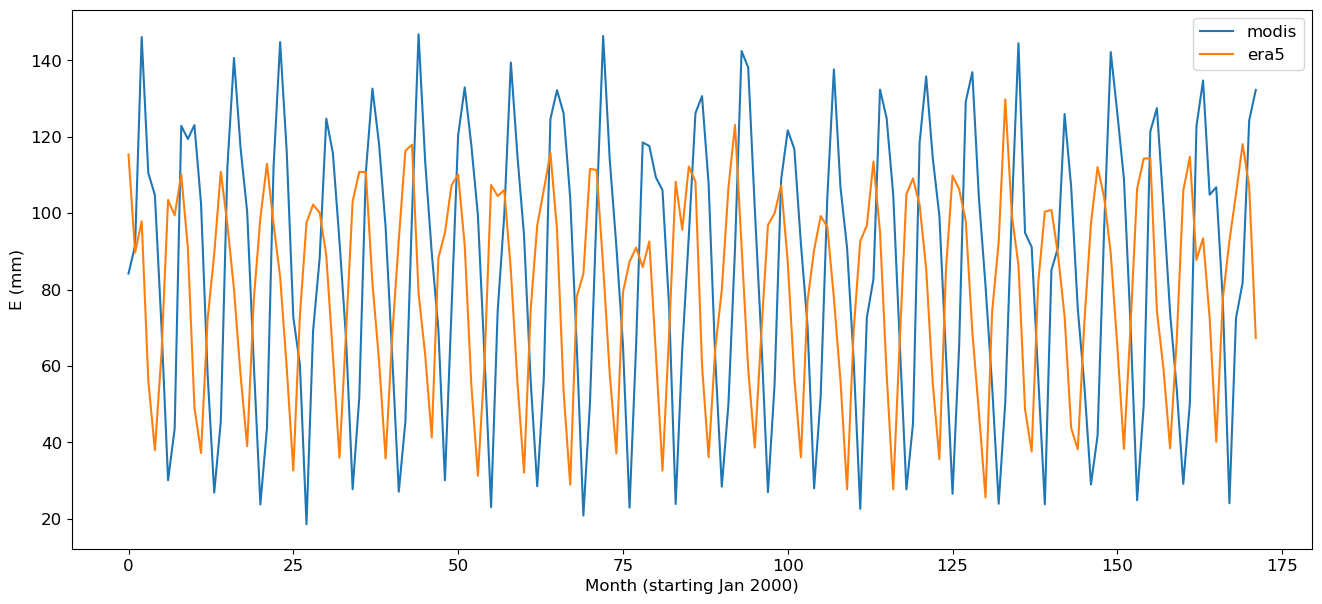

In [34]:
# Read and plot the monthly evaporation data
EObs1 = modis_monthly['monthly_ET'].to_numpy()
EObs2 = era5_evap['monthly'].to_numpy()
EObs2_aligned = EObs2[7:]
min_length = min(len(EObs1), len(EObs2_aligned))

EObs1_final = EObs1[:min_length]
EObs2_final = EObs2_aligned[:min_length]

#print(f"ERA5 original length: {len(EObs2)}")
#print(f"ERA5 after alignment: {len(EObs2_aligned)}")
#print(f"MODIS length: {len(EObs1)}")
#print(f"Final aligned length: {min_length}")

plt.figure(figsize=(16,7))
plt.plot(EObs1_final, label='modis')
plt.plot(EObs2_final, label='era5')
plt.legend()
plt.xlabel('Month (starting Jan 2000)')
plt.ylabel('E (mm)')
plt.show()

In [ ]:
# calculate means and perform uncertainty propagation for all 
# refer to Gerrit's notebook


In [ ]:
# FlexTOPO, get data and change as needed
DEM = np.genfromtxt('wark_data/dem.asc',  dtype=float, autostrip=True)
slope = np.genfromtxt('wark_data/slope.asc',  dtype=float, autostrip=True)
hand = np.genfromtxt('wark_data/HAND.asc',  dtype=float, autostrip=True)
basin = np.genfromtxt('wark_data/basin.asc',  dtype=float, autostrip=True) 

In [ ]:
# parameters: use result from Ex 4 (everything apart from beta) 
params = 

In [ ]:
# step 1: calibrate beta based on first x years
# incorporate flextopo 

# result: a relationship in the form of beta = y + a * temp 

In [ ]:
# step 2: use relationship obtained to get beta for other years, plot modelled Q vs actual Q 
betas = 



In [ ]:
# step 3: project Q 20 years ahead, using finalized model. 
# import projected temps, precipitation etc


In [ ]:
# results and discussion: Comment on discharge, flood risks etc. 